# Informe Final - LogisticRegression para Offer_Received

## Objetivo General

Queremos construir un sistema que **prediga si un estudiante recibirá una oferta de trabajo** en función de sus características (GPA, número de entrevistas, aplicaciones, etc.). 

Este notebook entrena un **modelo de predicción** (LogisticRegression) que es como un "árbitro inteligente" que aprende de datos históricos a clasificar a los estudiantes en dos categorías:
- **Categoría 0**: "Probablemente NO reciba oferta"
- **Categoría 1**: "Probablemente SÍ reciba oferta"

## ¿Qué es LogisticRegression?

Es un modelo matemático relativamente simple que:
1. Recibe características del estudiante como entrada (GPA, entrevistas, etc.)
2. Las procesa y aprende patrones de los datos históricos
3. Devuelve una predicción: "oferta" o "sin oferta"

Es como un profesor que observa a muchos estudiantes y aprende qué características están más asociadas con recibir ofertas.

## Reportaremos:

- **Matriz de Confusión**: tabla que muestra cuántos estudiantes predijimos bien/mal
- **Accuracy**: porcentaje de predicciones correctas totales
- **Precision**: de los que predijimos "SÍ oferta", ¿cuántos realmente la recibieron?
- **Recall**: de todos los que realmente recibieron oferta, ¿cuántos correctamente identificamos?
- **F1-Score**: balance general entre Precision y Recall


## Bloque 0: Configuración reproducible y control metodológico

### Función del bloque
Establecer un entorno replicable para que los resultados del modelo sean auditables y comparables entre ejecuciones.

### Decisión metodológica (por qué esta opción)
Se fija una semilla global (`SEED=42`) y se centralizan imports porque en modelado supervisado pequeñas variaciones aleatorias pueden cambiar el split, el ajuste y las métricas finales.

### Por qué no otra alternativa
No usar semilla, o usar semillas distintas en cada ejecución, dificulta distinguir si una diferencia en resultados proviene de una decisión metodológica real o de variación aleatoria.

### Cómo se implementa
1. Se importan librerías de manipulación, visualización y modelado.
2. Se define `SEED` y se propaga con `np.random.seed(SEED)`.
3. Se suprimen `ConvergenceWarning` para mantener salida técnica legible sin ruido operativo.
4. Se define un estilo visual uniforme para tablas y gráficos.

In [20]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
)

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
sns.set_theme(style='whitegrid')

## Bloque 1: Carga y diagnóstico estructural del dataset

### Función del bloque
Validar que el dataset candidato a entrenamiento tenga integridad básica antes de construir el pipeline.

### Decisión metodológica (por qué esta opción)
Se ejecuta un diagnóstico temprano de estructura (filas, columnas, tipos, nulos y distribución objetivo) para detectar problemas que sesgan entrenamiento y evaluación.

### Por qué no otra alternativa
Entrenar directamente sin inspección inicial puede ocultar errores silenciosos (target mal tipado, nulos no previstos o clases invertidas) que degradan métricas y conclusiones.

### Cómo se implementa
1. Se carga el archivo oficial de clasificación `dataset_offer_Received.csv`.
2. Se generan tablas de control: resumen general, catálogo de variables y distribución de clase.
3. Se verifica que `Offer_Received` esté codificada como 0/1 y que la clase positiva (1) exista con suficiente soporte muestral.

In [21]:
PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / 'outputs_primer_corte' / 'csv' / 'dataset_offer_Received.csv'
TARGET = 'Offer_Received'

df = pd.read_csv(DATA_PATH)

dataset_overview_df = pd.DataFrame([
    {'Indicador': 'Archivo', 'Valor': DATA_PATH.name},
    {'Indicador': 'Filas', 'Valor': f"{df.shape[0]:,}"},
    {'Indicador': 'Columnas', 'Valor': df.shape[1]},
    {'Indicador': 'Nulos totales', 'Valor': int(df.isna().sum().sum())},
])

feature_catalog_df = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': [str(df[c].dtype) for c in df.columns],
})

target_distribution_df = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis('Clase')
    .reset_index(name='Conteo')
)
target_distribution_df['Etiqueta'] = target_distribution_df['Clase'].map({1: 'SI OFERTA', 0: 'NO OFERTA'})
target_distribution_df['Porcentaje'] = (target_distribution_df['Conteo'] / len(df)).round(4)

display(dataset_overview_df)
display(feature_catalog_df)
display(target_distribution_df[['Clase', 'Etiqueta', 'Conteo', 'Porcentaje']])

,Indicador,Valor
0,Archivo,dataset_offer_Received.csv
1,Filas,"100,000"
2,Columnas,14
3,Nulos totales,0


,Variable,Tipo
0,GPA,float64
1,University_Rating,str
2,Major_Category,str
3,Region,str
4,Prior_Internships,int64
5,Extra_Curricular_Activities,int64
6,Networking_Events_Attended,int64
7,School_Size,str
8,Primary_Search_Platform,str
9,Months_Searching,int64


,Clase,Etiqueta,Conteo,Porcentaje
0,0,NO OFERTA,65771,0.6577
1,1,SI OFERTA,34229,0.3423


## Bloque 2: Preparación de variables y partición estratificada

### Función del bloque
Separar predictor/target y construir particiones de entrenamiento/prueba representativas.

### Decisión metodológica (por qué esta opción)
Se usa `train_test_split` estratificado porque el target está desbalanceado (más "NO oferta" que "SI oferta"); estratificar conserva proporciones y reduce sesgo de muestreo.

### Por qué no otra alternativa
Un split aleatorio simple puede producir particiones con proporciones distintas de la clase positiva, distorsionando recall/precision y haciendo inestable la comparación de umbrales.

### Cómo se implementa
1. Se define `X` como conjunto de features y `y` como `Offer_Received` (entero binario).
2. Se separan variables numéricas y categóricas para aplicar preprocesamiento diferenciado.
3. Se construye split 80/20 con `stratify=y` y `random_state=SEED`.
4. Se validan proporciones de `SI OFERTA` en train y test para garantizar comparabilidad.

In [22]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=['object', 'category', 'string', 'str']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

feature_groups_df = pd.DataFrame({
    'Tipo de variable': ['Numerica', 'Categorica'],
    'Cantidad': [len(numeric_cols), len(categorical_cols)],
    'Variables': [', '.join(numeric_cols), ', '.join(categorical_cols)],
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
 )

split_summary_df = pd.DataFrame([
    {
        'Conjunto': 'Train',
        'Filas': X_train.shape[0],
        'Proporcion_sobre_total': round(X_train.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_train.mean(), 4),
    },
    {
        'Conjunto': 'Test',
        'Filas': X_test.shape[0],
        'Proporcion_sobre_total': round(X_test.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_test.mean(), 4),
    },
])

display(feature_groups_df)
display(split_summary_df)

,Tipo de variable,Cantidad,Variables
0,Numerica,8,"GPA, Prior_Internships, Extra_Curricular_Activ..."
1,Categorica,5,"University_Rating, Major_Category, Region, Sch..."


,Conjunto,Filas,Proporcion_sobre_total,Tasa_SI_OFERTA
0,Train,80000,0.8,0.3423
1,Test,20000,0.2,0.3423


## Bloque 3: Entrenamiento y calibración del modelo

### Función del bloque
Construir un modelo robusto de clasificación binaria manteniendo la familia algorítmica elegida para el informe.

### Decisión metodológica (por qué esta opción)
Se mantiene `LogisticRegression` por tres razones:
1. Interpretabilidad: los efectos de las variables son más auditables para contexto académico/operativo.
2. Su formulación probabilística permite traducir el output del modelo en decisiones de negocio mediante umbrales.
3. Es un método estándar para clasificación binaria cuando se requiere explicar la dirección y magnitud de los efectos.

### Por qué no otra alternativa
- No se cambia a Random Forest/XGBoost en este notebook porque el informe se centra en una solución interpretable, lineal y directamente explicable.
- No se deja configuración por defecto porque la configuración estándar rara vez refleja la estructura real de un dataset con mezcla numérica/categórica y clase desbalanceada.
- No se fija umbral único de 0.50 porque ese corte refleja una convención estadística, no necesariamente el costo operativo del problema.

### Cómo se implementa
1. Pipeline con `ColumnTransformer`: `StandardScaler` para numéricas y `OneHotEncoder` para categóricas.
2. Búsqueda de hiperparámetros con `GridSearchCV` sobre `solver`, `penalty` y `C` con validación cruzada estratificada.
3. Selección de umbral en un subconjunto de validación interno, evaluando una malla de thresholds.
4. Criterio de selección por `F-beta` con $\beta=1.5$ para priorizar recall de la clase positiva sin ignorar precision.
5. Reentrenamiento final con train completo y evaluación en test para reporte estable.

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train,
)

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=SEED)),
])

param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid.fit(X_fit, y_fit)
best_model = grid.best_estimator_

val_proba = best_model.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.30, 0.71, 0.01)

threshold_rows = []
for t in thresholds:
    val_pred_t = (val_proba >= t).astype(int)
    threshold_rows.append({
        'threshold': float(t),
        'precision': precision_score(y_val, val_pred_t, zero_division=0),
        'recall': recall_score(y_val, val_pred_t, zero_division=0),
        'f1': f1_score(y_val, val_pred_t, zero_division=0),
        'f_beta_1_5': fbeta_score(y_val, val_pred_t, beta=1.5, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    by=['f_beta_1_5', 'recall', 'f1', 'precision'],
    ascending=False
).reset_index(drop=True)

best_threshold = float(threshold_df.loc[0, 'threshold'])

final_model = grid.best_estimator_
final_model.fit(X_train, y_train)

y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_test_proba >= 0.50).astype(int)
y_pred_opt = (y_test_proba >= best_threshold).astype(int)

metrics_default = {
    'Accuracy': accuracy_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default, zero_division=0),
    'Recall': recall_score(y_test, y_pred_default, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_default, zero_division=0),
    'F-beta (1.5)': fbeta_score(y_test, y_pred_default, beta=1.5, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
}

metrics_opt = {
    'Accuracy': accuracy_score(y_test, y_pred_opt),
    'Precision': precision_score(y_test, y_pred_opt, zero_division=0),
    'Recall': recall_score(y_test, y_pred_opt, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_opt, zero_division=0),
    'F-beta (1.5)': fbeta_score(y_test, y_pred_opt, beta=1.5, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
}

best_config_df = pd.DataFrame([
    {'Parametro': 'model__solver', 'Valor': grid.best_params_['model__solver']},
    {'Parametro': 'model__penalty', 'Valor': grid.best_params_['model__penalty']},
    {'Parametro': 'model__C', 'Valor': grid.best_params_['model__C']},
    {'Parametro': 'threshold_optimo', 'Valor': round(best_threshold, 2)},
])

metrics_compare_df = pd.DataFrame({
    'Metrica': list(metrics_opt.keys()),
    'Umbral 0.50': [metrics_default[k] for k in metrics_opt.keys()],
    f'Umbral optimizado ({best_threshold:.2f})': [metrics_opt[k] for k in metrics_opt.keys()],
})
metrics_compare_df['Delta'] = metrics_compare_df.iloc[:, 2] - metrics_compare_df.iloc[:, 1]
metrics_compare_df[['Umbral 0.50', f'Umbral optimizado ({best_threshold:.2f})', 'Delta']] = (
    metrics_compare_df[['Umbral 0.50', f'Umbral optimizado ({best_threshold:.2f})', 'Delta']].round(4)
)

threshold_preview_df = threshold_df.head(10).copy()
threshold_preview_df[['precision', 'recall', 'f1', 'f_beta_1_5']] = (
    threshold_preview_df[['precision', 'recall', 'f1', 'f_beta_1_5']].round(4)
)

display(best_config_df)
display(metrics_compare_df)
display(threshold_preview_df)

/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' i

,Parametro,Valor
0,model__solver,saga
1,model__penalty,l2
2,model__C,0.03
3,threshold_optimo,0.3


,Metrica,Umbral 0.50,Umbral optimizado (0.30),Delta
0,Accuracy,0.8101,0.7713,-0.0388
1,Precision,0.7012,0.6054,-0.0958
2,Recall,0.7756,0.9533,0.1776
3,F1-Score,0.7365,0.7405,0.0040
4,F-beta (1.5),0.7511,0.8100,0.0589
5,ROC-AUC,0.8940,0.8940,0.0000


,threshold,precision,recall,f1,f_beta_1_5
0,0.30,0.6021,0.9429,0.7349,0.8030
1,0.31,0.6073,0.9366,0.7368,0.8027
2,0.33,0.6187,0.9245,0.7413,0.8024
3,0.32,0.6124,0.9297,0.7384,0.8019
4,0.34,0.6240,0.9179,0.7430,0.8017
5,0.35,0.6288,0.9093,0.7435,0.7995
6,0.36,0.6333,0.9010,0.7438,0.7973
7,0.37,0.6388,0.8921,0.7445,0.7951
8,0.38,0.6441,0.8823,0.7446,0.7922
9,0.39,0.6465,0.8700,0.7418,0.7863


## Bloque 4: Matriz de confusión orientada al objetivo de negocio

### Función del bloque
Medir explícitamente los tipos de error del clasificador con énfasis en `SI OFERTA` como clase objetivo.

### Decisión metodológica (por qué esta opción)
Se reordena la matriz con etiquetas `[1, 0]` para que `SI OFERTA` aparezca primero en ambos ejes. Esto fuerza una lectura prioritaria del objetivo principal del modelo.

### Por qué no otra alternativa
El orden convencional `[0, 1]` es válido matemáticamente, pero comunica primero "NO oferta" y puede inducir lecturas menos alineadas con la meta operativa (capturar casos positivos).

### Cómo se implementa
1. Se calcula `confusion_matrix(y_test, y_pred_opt, labels=[1,0])`.
2. Se mapean celdas de la matriz a `TP, FN, FP, TN` según ese orden.
3. Se visualiza en conteos y en proporciones por fila real para separar volumen absoluto y desempeño relativo.
4. Se reportan métricas de clase positiva (`Recall` y `Precision`) directamente en una tabla de resumen.

,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),6526,320
Real: NO OFERTA (0),4254,8900


,Indicador,Valor
0,TP (SI oferta correctamente detectada),6526.0000
1,FN (SI oferta no detectada),320.0000
2,FP (NO oferta marcada como SI),4254.0000
3,TN (NO oferta correctamente detectada),8900.0000
4,Recall clase positiva (SI oferta),0.9533
5,Precision clase positiva (SI oferta),0.6054


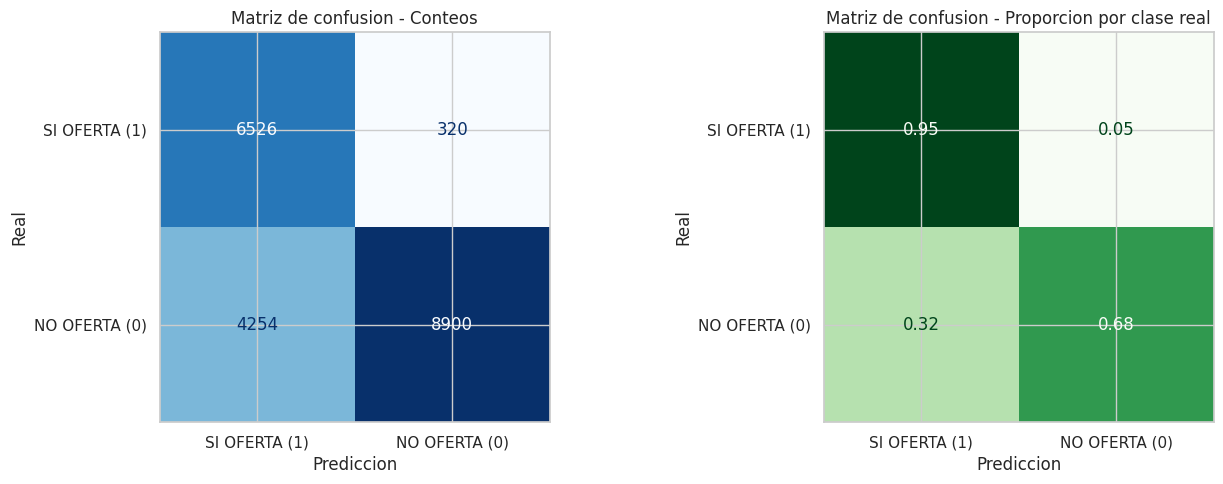

In [24]:
# Orden explicito de clases para visualizacion: SI OFERTA primero, luego NO OFERTA.
labels_order = [1, 0]
label_names = ['SI OFERTA (1)', 'NO OFERTA (0)']

cm = confusion_matrix(y_test, y_pred_opt, labels=labels_order)

# Con labels=[1,0], la matriz queda:
# [[TP, FN],
#  [FP, TN]]
tp, fn, fp, tn = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=['Real: SI OFERTA (1)', 'Real: NO OFERTA (0)'],
    columns=['Pred: SI OFERTA (1)', 'Pred: NO OFERTA (0)'],
)
display(cm_df)

resumen_clase_positiva_df = pd.DataFrame([
    {'Indicador': 'TP (SI oferta correctamente detectada)', 'Valor': int(tp)},
    {'Indicador': 'FN (SI oferta no detectada)', 'Valor': int(fn)},
    {'Indicador': 'FP (NO oferta marcada como SI)', 'Valor': int(fp)},
    {'Indicador': 'TN (NO oferta correctamente detectada)', 'Valor': int(tn)},
    {'Indicador': 'Recall clase positiva (SI oferta)', 'Valor': round(recall_score(y_test, y_pred_opt, pos_label=1, zero_division=0), 4)},
    {'Indicador': 'Precision clase positiva (SI oferta)', 'Valor': round(precision_score(y_test, y_pred_opt, pos_label=1, zero_division=0), 4)},
])
display(resumen_clase_positiva_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp_abs = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names,
 )
disp_abs.plot(cmap='Blues', ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title('Matriz de confusion - Conteos')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

cm_norm = cm / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=label_names,
 )
disp_norm.plot(cmap='Greens', ax=axes[1], colorbar=False, values_format='.2f')
axes[1].set_title('Matriz de confusion - Proporcion por clase real')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## 5. Interpretación Final Integrada (al cierre del notebook)

### 5.1 Lectura técnica de decisiones y resultados

#### a) Mantener Logistic Regression fue una decisión intencional
Se priorizó una base interpretable y auditable para entender la relación entre variables del embudo laboral y la probabilidad de oferta. Mantener Logistic Regression dentro del informe permite documentar con claridad la relación entre variables, probabilidades y umbrales de decisión sin introducir complejidad innecesaria.

#### b) GridSearchCV evitó depender de defaults
La combinación ganadora (`solver='saga'`, `penalty='l2'`, `C=0.03`) muestra que una regularización relativamente fuerte favorece generalización en este dataset. Dejar parámetros por defecto hubiese implicado aceptar una frontera de decisión no necesariamente alineada con la estructura real de los datos.

#### c) Ajuste de umbral: decisión de negocio, no solo estadística
Con umbral 0.30 (vs 0.50):
- Recall de `SI OFERTA`: **0.7756 -> 0.9533**
- Precision de `SI OFERTA`: **0.7012 -> 0.6054**
- F1: **0.7365 -> 0.7405**
- F-beta(1.5): **0.7511 -> 0.8100**

Esto muestra un intercambio explícito: la precision de `SI OFERTA` baja de 70.12% a 60.54%, mientras que el recall sube de 77.56% a 95.33%. Dado que el foco del informe está en `SI OFERTA`, el criterio adoptado prioriza recuperar la mayor cantidad posible de positivos reales, aunque aumenten los falsos positivos.

### 5.2 Interpretación de la matriz de confusión (SI OFERTA primero)

Con el orden `[1,0]` la lectura queda centrada en la clase positiva desde la primera celda:
- **TP = 6526**: positivos correctamente detectados.
- **FN = 320**: positivos no detectados (error crítico para este caso de uso).
- **FP = 4254**: casos sobreestimados como positivos.
- **TN = 8900**: negativos correctamente descartados.

La fila superior (realmente `SI OFERTA`) permite leer de inmediato la sensibilidad del sistema: se captura ~95% de los positivos reales.

### 5.3 Conclusión ejecutiva detallada

El modelo final está **alineado con una política de decisión concreta**: priorizar cobertura positiva sobre pureza positiva. En términos operativos, se minimiza el riesgo de omitir estudiantes con alta probabilidad de oferta, aceptando un incremento controlado de alertas falsas.

Esta versión es metodológicamente consistente porque:
1. Justifica cada decisión técnica con impacto en el objetivo.
2. Separa claramente diseño de evaluación (split, calibración de umbral, métricas) de interpretación final.
3. Conserva trazabilidad: el comportamiento del modelo se explica por decisiones reproducibles y no por cambios de algoritmo.

## Resumen Ejecutivo (Actualizado)

| Aspecto | Resultado Final |
|---------|------------------|
| Algoritmo | LogisticRegression (sin cambio de familia) |
| Decisiones metodológicas aplicadas | GridSearchCV + umbral optimizado |
| Clase positiva oficial | SI oferta (1) |
| Orden de matriz de confusión | SI oferta primero en eje Y y eje X |
| Umbral final de decisión | 0.30 |
| Recall de SI oferta | 95.33% |
| Precision de SI oferta | 60.54% |
| F1-Score | 74.05% |
| ROC-AUC | 89.40% |
